<a href="https://colab.research.google.com/github/Lucas-O-S/Modelos_Classificat-rios_IA_N2/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AVALIAÇÃO N2 - Inteligência Artificial

## Dataset: Telco Customer Churn
O conjunto de dados reúne informações sobre clientes de uma empresa de telecomunicações com o objetivo de analisar e prever o cancelamento de clientes (churn) para que, assim, consigam desenvolver estratégias de retenção.

**Nomes e RAs:**

Adriana Kaori Kakazu - 082220004

Beatriz dos Santos Buglio - 082220028

Lucas Oliveira Silva - 082220019

Vitoria Kaori Kuriyama - 082220005

**Modelos de Classificação:**
*   Regressão Logística;
*   Árvore de Decisão;
*   Naive Bayes;
*   KNN;
*   Rede neural (Perceptron simples).

## 1. Configuração do ambiente e carregamento dos dados

In [61]:
# Tratamento dos dados
import numpy as np
import pandas as pd
from collections import Counter

# Carregamento de dados do OpenML
from sklearn.datasets import fetch_openml

# Pré-processamento e Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Métricas de avaliação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, classification_report
# removed plot_roc_curve as it is deprecated
# Plot dos gráficos
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
import seaborn as sns

#Check scikit-learn version
import sklearn
print(sklearn.__version__) # make sure the version is 0.23 or higher

#If the version is lower than 0.23, update scikit-learn
!pip install -U scikit-learn

1.9.1


In [62]:
# Paleta de cores padrão para todos os gráficos, sem precisar passar a cor em cada um
sns.set_palette("viridis")

# Mostra todas as colunas do DataFrame, sem abreviar com "..."
pd.set_option('display.max_columns', None)

In [63]:
# Criação do RANDOM_STATE para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [64]:
urlDataset = "https://raw.githubusercontent.com/Lucas-O-S/Modelos_Classificat-rios_IA_N2/refs/heads/main/Telco%20Customer%20Churn.csv"

In [65]:
data = pd.read_csv(urlDataset)

## 2. Fazer a análise exploratória dos dados



### 2.1 Análise e observação dos dados

In [66]:
# Tipos de dado de cada coluna e quantos valores não-nulos existem
print(f"Formato do dataset: {data.shape[0]} linhas x {data.shape[1]} colunas")
data.info()

Formato do dataset: 7043 linhas x 21 colunas
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Paperles

In [67]:
# Analisa se há dados faltantes ou duplicados
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor ausente encontrado.")

print(f"Linhas duplicadas: {data.duplicated().sum()}")

Nenhum valor ausente encontrado.
Linhas duplicadas: 0


In [68]:
# Cinco primeiras linhas do dataset
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [69]:
# Contagem de quantas vezes cada valor aparece na coluna "Churn"
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

É possível ver que os dados são desbalanceados, sendo cerca de 73,5% para "Não" e 26,5% para "Sim".

In [70]:
# Estatísticas básicas das colunas numéricas (média, desvio padrão, mínimo, máximo etc.)
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Aqui percebemos que somente três das vinte colunas apresentam valores numéricos.

In [71]:
# Remoção do "customerID", pois ele não carrega informação preditiva
data_sem_id = data.drop(columns=['customerID'])

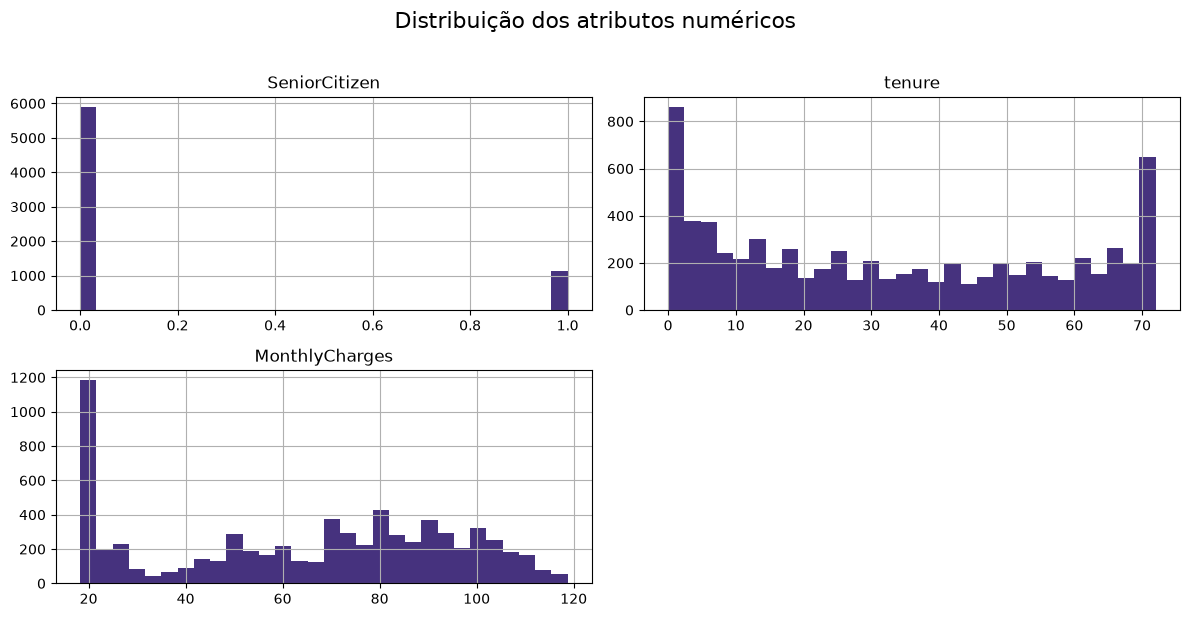

In [72]:
data_sem_id.hist(bins=30, figsize=(12, 6))
plt.suptitle("Distribuição dos atributos numéricos", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Nessa etapa, somente três colunas são numéricas: `SeniorCitizen`, `tenure` e `MonthlyCharges` (a `TotalCharges`, apesar de representar valores, ainda está armazenada como texto e será convertida na seção 2.2).

* `SeniorCitizen` - apesar de numérica, é uma variável binária: apenas 16,2% dos clientes são idosos;
* `tenure` - apresenta dois picos nas extremidades: muitos clientes recentes (624 com até 1 mês) e muitos clientes antigos (651 com 70 meses ou mais), indicando que a base mistura clientes novos e clientes fidelizados;
* `MonthlyCharges` - concentra muitos clientes na faixa de até 25 (1.406), que correspondem, em grande parte, aos 1.526 clientes sem serviço de internet (média de 21,08 mensais), enquanto a maior parte dos demais está entre 60 e 100.

Como somente colunas numéricas foram levadas em consideração, percebe-se que a quantidade de features parecem insuficientes.
Para resolver isso, mudamos o tipo de dado das colunas para observar se há resultados interessantes para serem usados no treinamento e teste.

### 2.2 Conversão dos dados

In [73]:
# Inicialmente, como nosso alvo é do tipo object ("Yes"/"No"), convertemos para inteiro
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})
data["Churn"].dtype

dtype('int64')

In [74]:
# Transformando TotalCharges para um tipo numérico
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"].dtype

dtype('float64')

In [75]:
# Testando se houve alterações após a conversão
print(f"Registros com TotalCharges ausente: {data['TotalCharges'].isna().sum()}")
print(f"Linhas duplicadas: {data.duplicated().sum()}")

Registros com TotalCharges ausente: 11
Linhas duplicadas: 0


Onze clientes ficaram com `TotalCharges` ausente, são clientes com `tenure` = 0, ou seja, acabaram de assinar e ainda não fecharam sua primeira fatura.

Logo, por mais que possuam um valor vazio, estes ainda são dados importantes no dataset, portanto iremos transformar esses valores vazios em 0.

In [76]:
# Preenchendo valores vazios com 0
data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [77]:
# Testando novamente
print(f"Registros com TotalCharges ausente: {data['TotalCharges'].isna().sum()}")
print(f"Linhas duplicadas: {data.duplicated().sum()}")

Registros com TotalCharges ausente: 0
Linhas duplicadas: 0


Para o tratamento das variáveis categóricas, utilizamos o método `get_dummies()`, da biblioteca Pandas, que permite transformar variáveis categóricas em variáveis "dummy".

As variáveis dummy são representações numéricas de variáveis categóricas, onde cada categoria é convertida em uma nova coluna binária. Dessa forma, cada coluna indica, por meio dos valores 0 e 1, a ausência ou a presença de determinada categoria em cada observação do conjunto de dados original.

In [78]:
# Separação das colunas entre target, features e colunas para ignorar
coluna_alvo = "Churn"
colunas_para_ignorar = ['customerID']

colunas_para_remover = colunas_para_ignorar + [coluna_alvo]
X = data.drop(columns=colunas_para_remover)
y = data[coluna_alvo]

In [79]:
# Separação das colunas categóricas
colunas_categoricas = X.select_dtypes(include=["object", "str"]).columns.tolist()
print(f"Colunas categóricas ({len(colunas_categoricas)}): {colunas_categoricas}")

Colunas categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [80]:
# Utilização do método "get_dummies()" e visualização do resultado final
X = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)
print(f"Resultado final: {X.shape}")
X.head()

Resultado final: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [81]:
# Visualização do dataset depois das alterações
print(f"Formato do dataset: {X.shape[0]} linhas x {X.shape[1]} colunas")
X.info()

Formato do dataset: 7043 linhas x 30 colunas
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   bool   
 5   Partner_Yes                            7043 non-null   bool   
 6   Dependents_Yes                         7043 non-null   bool   
 7   PhoneService_Yes                       7043 non-null   bool   
 8   MultipleLines_No phone service         7043 non-null   bool   
 9   MultipleLines_Yes                      7043 non-null   bool   
 10  InternetService_Fiber optic           

### OBRIGATÓRIO: Explicar quais features estão envolvidas e o seu respectivo target

**Target**

`Churn` - Indica se o cliente cancelou o serviço (Yes = 1) ou permaneceu (No = 0).

**Features**

Todas as colunas, exceto `customerID` e `Churn`.

**Dados demográficos**

* `gender` - gênero do cliente (`Male`/`Female`)
* `SeniorCitizen` - indica se o cliente é idoso (`1`) ou não (`0`)
* `Partner` - indica se possui cônjuge/parceiro(a) (`Yes`/`No`)
* `Dependents` - indica se possui dependentes (`Yes`/`No`)

**Relacionamento com a empresa e serviços contratados**

* `tenure` - tempo, em meses, que o cliente está na empresa
* `PhoneService` - indica se possui serviço de telefonia
* `MultipleLines` - indica se possui múltiplas linhas
* `InternetService` - tipo de serviço de internet (`DSL`, `Fiber optic` ou `None`)
* `OnlineSecurity` - contratação do serviço de segurança online
* `OnlineBackup` - contratação do serviço de backup online
* `DeviceProtection` - contratação de proteção para dispositivos
* `TechSupport` - contratação de suporte técnico
* `StreamingTV` - contratação do serviço de streaming de TV
* `StreamingMovies` - contratação do serviço de streaming de filmes

**Dados contratuais e financeiros**

* `Contract` - tipo de contrato (`mensal`, `1 ano` ou `2 anos`)
* `PaperlessBilling` - indica se a fatura é digital (`Yes`/`No`)
* `PaymentMethod` - forma de pagamento utilizada
* `MonthlyCharges` - valor cobrado mensalmente (numérico)
* `TotalCharges` - valor total cobrado durante o relacionamento com a empresa (numérico)

## 3. Dividir os dados em conjunto de treinamento e treinar os modelos

O conjunto de dados foi dividido em 80% para treino (5.634 clientes) e 20% para teste (1.409 clientes), utilizando o `train_test_split` do scikit-learn com `random_state` = 42 para garantir a reprodutibilidade da divisão.

Como os dados são desbalanceados (cerca de 26,5% de churn), utilizamos o parâmetro `stratify=y`, que mantém a mesma proporção de clientes que cancelaram e que permaneceram nos dois conjuntos. Sem a estratificação, o conjunto de teste poderia ficar, por acaso, com uma proporção de churn diferente da real, prejudicando a avaliação dos modelos.

O conjunto de treino é utilizado para o aprendizado dos modelos, enquanto o conjunto de teste é reservado para a avaliação final, com clientes que os modelos nunca viram.

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {len(X_train)} linhas | Teste: {len(X_test)} linhas")


Treino: 5634 linhas | Teste: 1409 linhas


Antes de incluir novos atributos no pipeline, testamos dois atributos derivados em uma cópia do conjunto de treino (`X_train_extra`), para não alterar o `X_train` oficial e sem utilizar o conjunto de teste:

* `TotalChargesPerMonth` - gasto médio mensal do cliente, calculado por `TotalCharges` / `tenure`. Para os clientes com `tenure` = 0 a divisão não é possível, então é utilizado o valor de `MonthlyCharges`;
* `serviceQuantity` - quantidade de serviços adicionais contratados (segurança online, backup online, proteção de dispositivos, suporte técnico, streaming de TV e streaming de filmes), variando de 0 a 6.

Para avaliar se os atributos são úteis, verificamos a correlação de cada um com o `Churn` e se eles repetem a informação de alguma coluna já existente.

tenure                 -0.346
MonthlyCharges          0.198
TotalCharges           -0.194
TotalChargesPerMonth    0.197
serviceQuantity        -0.084
Name: Churn, dtype: float64

Correlação TotalChargesPerMonth x MonthlyCharges: 0.996

Taxa de churn por quantidade de serviços:
serviceQuantity
0    0.209
1    0.458
2    0.362
3    0.278
4    0.230
5    0.125
6    0.047
Name: Churn, dtype: float64


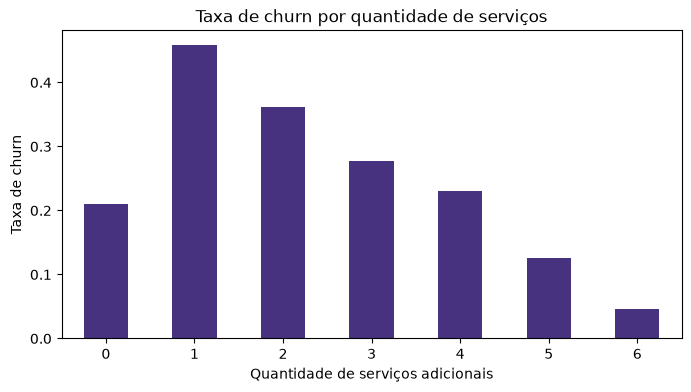

In [83]:
# Cópia do treino para testar os atributos derivados sem alterar o X_train oficial
X_train_extra = X_train.copy()

# gasto médio por mês (tenure 0 vira NaN e é preenchido com MonthlyCharges)
X_train_extra['TotalChargesPerMonth'] = (X_train_extra['TotalCharges'] / X_train_extra['tenure'].replace(0, np.nan)).fillna(X_train_extra['MonthlyCharges'])

# quantidade de serviços adicionais contratados (colunas já em dummy)
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
X_train_extra['serviceQuantity'] = X_train_extra[[s + '_Yes' for s in services]].sum(axis=1)

# Correlação de cada atributo com o Churn (astype(float) converte as colunas dummy True/False em 1/0)
corr_check = pd.concat([X_train_extra.astype(float), y_train], axis=1).corr()['Churn']
print(corr_check[['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalChargesPerMonth', 'serviceQuantity']].round(3))

# Verifica se o novo atributo repete a informação de uma coluna já existente
print(f"\nCorrelação TotalChargesPerMonth x MonthlyCharges: {X_train_extra['TotalChargesPerMonth'].corr(X_train_extra['MonthlyCharges']):.3f}")

# Taxa de churn por quantidade de serviços
taxa_churn = pd.concat([X_train_extra['serviceQuantity'], y_train], axis=1).groupby('serviceQuantity')['Churn'].mean()
print(f"\nTaxa de churn por quantidade de serviços:\n{taxa_churn.round(3)}")

taxa_churn.plot(kind='bar', figsize=(8, 4))
plt.xlabel("Quantidade de serviços adicionais")
plt.ylabel("Taxa de churn")
plt.title("Taxa de churn por quantidade de serviços")
plt.xticks(rotation=0)
plt.show()

Os resultados mostram que:

* `TotalChargesPerMonth` possui correlação de 0,197 com o `Churn`, praticamente igual à de `MonthlyCharges` (0,198). Além disso, sua correlação com `MonthlyCharges` é de 0,996, ou seja, o novo atributo é quase uma cópia de uma coluna já existente e não acrescenta informação nova. Por isso, ele foi descartado;
* `serviceQuantity` possui correlação linear fraca com o `Churn` (−0,084), porém o gráfico mostra uma relação clara que a correlação de Pearson não consegue capturar, por não ser linear: a taxa de churn cai de 45,8% entre os clientes com 1 serviço para 4,7% entre os clientes com 6 serviços. O grupo com 0 serviços apresenta taxa menor (20,9%) porque inclui os clientes sem internet, que não podem contratar esses serviços. Por isso, esse atributo foi mantido.

Com base nessa análise, somente o `serviceQuantity` é adicionado ao pipeline final. Ele é criado dentro de uma classe que herda de `BaseEstimator` e `TransformerMixin`, o que permite utilizá-la como uma etapa do `Pipeline`, lado a lado com transformadores prontos do scikit-learn, como o `StandardScaler`.

In [84]:

class DerivatedAtributes(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # quantidade de serviços adicionais contratados (colunas já em dummy)
        # TotalChargesPerMonth foi descartado na análise acima por ser redundante com MonthlyCharges
        services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
        
        X['serviceQuantity'] = X[[s + '_Yes' for s in services]].sum(axis=1)

        return X

numColumns = ['tenure', 'MonthlyCharges', 'TotalCharges', 'serviceQuantity']


Os atributos numéricos possuem escalas muito diferentes: `tenure` varia de 0 a 72 meses, enquanto `TotalCharges` ultrapassa 8.000. Modelos baseados em distância, como o KNN, e modelos que utilizam pesos, como a Regressão Logística e o Perceptron, tendem a dar mais importância aos atributos com valores maiores apenas por causa da escala.

Para evitar isso, utilizamos o `StandardScaler`, que padroniza cada coluna pela fórmula (x − média) / desvio padrão, deixando todas com média 0 e desvio padrão 1. Por meio do `ColumnTransformer`, a padronização é aplicada apenas às colunas numéricas (`numColumns`); as colunas dummy, que já assumem somente os valores 0 e 1, passam sem alteração (`remainder='passthrough'`).

In [85]:
# padroniza só as numéricas; as colunas dummy (0/1) passam direto
preProcess = ColumnTransformer([
    ('num', StandardScaler(), numColumns),
], remainder='passthrough')

fullPipe = Pipeline([
    ('attribs_adder', DerivatedAtributes()),
    ('prep', preProcess),
])

xTrainPrepared = fullPipe.fit_transform(X_train)
xTestPrepared = fullPipe.transform(X_test)

print(xTrainPrepared.shape, xTestPrepared.shape)

(5634, 31) (1409, 31)


Todo o pré-processamento foi encapsulado em um `Pipeline` do scikit-learn, que executa as etapas sempre na mesma ordem: primeiro a criação do atributo derivado e, em seguida, a padronização das colunas numéricas.

O método `fit_transform()` é aplicado somente no conjunto de treino: nele, o `StandardScaler` aprende a média e o desvio padrão de cada coluna e já aplica a transformação. No conjunto de teste é utilizado apenas o `transform()`, que reaproveita os valores aprendidos no treino. Dessa forma, nenhuma informação do teste é utilizada durante o preparo dos dados, evitando o vazamento de dados (*data leakage*), e o teste continua representando clientes nunca vistos pelos modelos.

Como resultado, ambos os conjuntos passam a ter 31 colunas: as 30 originais mais o atributo derivado `serviceQuantity`.

## 4. Metricas de desempenho

[Precisão, Revocação, Acurácia e F1-Score]

## 5. Conclusão

Os resultados estão bons?